Imports

In [86]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
import numpy as np
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt

## Data Preprocessing

Load Datasets

In [87]:
movies = pd.read_csv('movies.csv')
ratings_train = pd.read_csv('ratings_train.csv')
test_df = pd.read_csv('ratings_test.csv')

Encoding Categorical Features (Genres)

In [88]:
# create genre columns
movies['genre_list'] = movies['genres'].str.split('|')
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(movies['genre_list']),
    columns=mlb.classes_,
    index=movies.index
)
movies_cleaned = pd.concat([movies, genre_encoded], axis=1)

# drop redundant columns
cols_to_drop = ['genres', 'genre_list', '(no genres listed)']
movies_cleaned = movies_cleaned.drop(columns=cols_to_drop)

# display the head to verify the change
display(movies_cleaned.head())

,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Join Datasets

In [89]:
df_combined = pd.merge(ratings_train, movies_cleaned, on='movieId', how='left')
df_combined['rating'] = (df_combined['rating'] * 2).astype(int) # rescale rating
train_data = df_combined[['userId', 'movieId', 'rating']]
display(train_data.head())

,userId,movieId,rating
0,1,1,8
1,1,3,8
2,1,6,8
3,1,47,10
4,1,50,10


Data Distribution

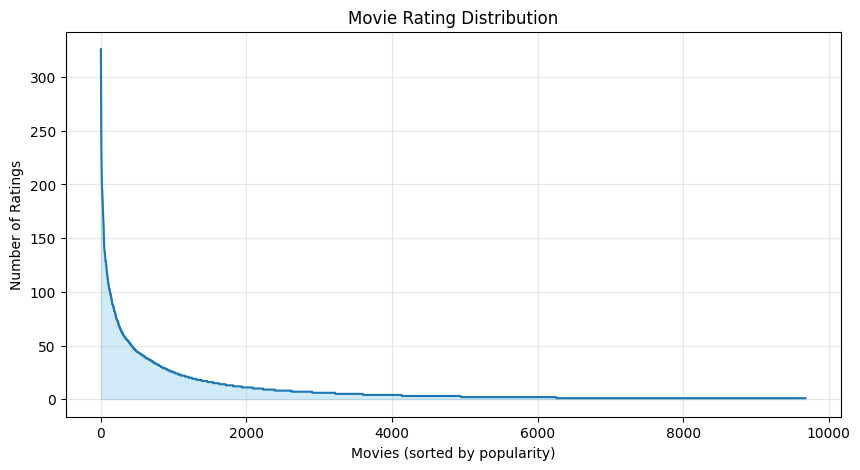

In [90]:
# count ratings per movie
movie_counts = df_combined['movieId'].value_counts().values

# plot
plt.figure(figsize=(10, 5))
plt.plot(movie_counts)
plt.title('Movie Rating Distribution')
plt.xlabel('Movies (sorted by popularity)')
plt.ylabel('Number of Ratings')
plt.fill_between(range(len(movie_counts)), movie_counts, color='skyblue', alpha=0.4)
plt.grid(alpha=0.3)
plt.savefig('distribution.png')
plt.show()

## Model Training

Collaborative Filtering

In [91]:
def setup_cf(data):
    # create interaction matrix
    pivot_table = data.pivot(index='userId', columns='movieId', values='rating').fillna(0)

    # compute cosine similarity
    sparse_matrix = csr_matrix(pivot_table.values)
    user_sim = cosine_similarity(sparse_matrix)
    user_sim_df = pd.DataFrame(user_sim, index=pivot_table.index, columns=pivot_table.index)
    return pivot_table, user_sim_df

def run_user_based_cf(target_user, pivot_table, user_sim_df, count=10):
    if target_user not in user_sim_df.index: return pd.Series(dtype=float)

    # find top similar users
    similar_users = user_sim_df[target_user].sort_values(ascending=False).iloc[1:11].index

    # filter already seen movies
    target_seen_movies = pivot_table.loc[target_user][pivot_table.loc[target_user] > 0].index

    # average ratings from similar users (movies the target user hasn't seen)
    similar_users_ratings = pivot_table.loc[similar_users]
    recs_df = similar_users_ratings.mean().drop(index=target_seen_movies)
    recs_df.name = 'cf_recommendations'

    return recs_df.sort_values(ascending=False).head(count)

# test
pivot_cf, sim_df = setup_cf(train_data)
recommendations = run_user_based_cf(target_user=1, pivot_table=pivot_cf, user_sim_df=sim_df)
print(recommendations)

movieId
589     8.4
1200    8.2
2762    8.0
1610    7.9
858     7.8
924     7.7
1036    7.6
541     7.4
1221    7.2
1968    7.2
Name: cf_recommendations, dtype: float64


Matrix Factorization

In [92]:
def setup_svd(data, k=50):
    # create interaction matrix
    pivot_table = data.pivot(index='userId', columns='movieId', values='rating').fillna(0)
    matrix = pivot_table.values
    user_ratings_mean = np.mean(matrix, axis=1)
    matrix_demeaned = matrix - user_ratings_mean.reshape(-1, 1)

    # perform Matrix Factorization (SVD)
    U, sigma, Vt = svds(matrix_demeaned, k=k)
    sigma = np.diag(sigma)

    # reconstruct the matrix to get predicted ratings
    all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)
    preds_df = pd.DataFrame(all_user_predicted_ratings, columns=pivot_table.columns, index=pivot_table.index)
    return pivot_table, preds_df

def run_matrix_factorization(target_user, pivot_table, preds_df, count=10):
    if target_user not in preds_df.index: return pd.Series(dtype=float)

    # get and sort the users predictions
    sorted_user_predictions = preds_df.loc[target_user].sort_values(ascending=False)

    # filter already seen movies
    target_seen_movies = pivot_table.loc[target_user][pivot_table.loc[target_user] > 0].index

    # recommend movies the user hasn't seen yet
    recs_df = sorted_user_predictions.drop(index=target_seen_movies)
    recs_df.name = 'mf_recommendations'

    return recs_df.head(count)

# test
pivot_mf, predictions_df = setup_svd(train_data)
recommendations = run_matrix_factorization(target_user=1, pivot_table=pivot_mf, preds_df=predictions_df)
print(recommendations)

movieId
1036    8.463808
1387    6.899323
1221    6.240825
858     5.662643
1968    5.241620
1259    5.228827
4011    5.091337
589     4.779823
2804    4.766189
2918    4.587786
Name: mf_recommendations, dtype: float64


Evaluation

In [93]:
# split the data
SEED = 99
train, test = train_test_split(train_data, test_size=0.2, random_state=SEED)

# setup both models
pivot_cf, sim_df = setup_cf(train)
pivot_mf, preds_df = setup_svd(train)

def evaluate_model(model_func, pivot_table, model_data, name, k=10):
    # ratings
    precisions, recalls, rmses, novelties = [], [], [], []

    # get global popularity for novelty
    item_pop = train.groupby('movieId').size() / train['userId'].nunique()

    # test on users present in both sets
    test_users = [u for u in test['userId'].unique() if u in pivot_table.index][:100]

    for user in test_users:
        # actual high-rated movies from test set
        user_test = test[test['userId'] == user]
        actual_rel = user_test[user_test['rating'] >= 4]['movieId'].values
        if len(actual_rel) == 0: continue

        # get recommendations
        recs = model_func(user, pivot_table, model_data, count=k)
        recs_ids = recs.index.tolist()

        # precision and recall
        hits = len(set(recs_ids) & set(actual_rel))
        precisions.append(hits / k)
        recalls.append(hits / len(actual_rel))

        # novelty (unexpectedness)
        novelties.append(-np.mean([np.log2(item_pop.get(m, 1e-6)) for m in recs_ids]))

        # rmse (on items that exist in both recs and test set)
        common = set(recs_ids) & set(user_test['movieId'])
        for m in common:
            actual = user_test[user_test['movieId'] == m]['rating'].values[0]
            rmses.append((actual - recs[m])**2)

    # calculate final values
    res_rmse = np.sqrt(np.mean(rmses))
    res_prec = np.mean(precisions)
    res_rec = np.mean(recalls)
    res_nov = np.mean(novelties)

    print(f"--- {name} ---")
    print(f"RMSE:      {res_rmse:.4f}")
    print(f"Precision: {res_prec:.4f}")
    print(f"Recall:    {res_rec:.4f}")
    print(f"Novelty:   {res_nov:.4f}\n")

    return [res_rmse, res_prec, res_rec, res_nov]

# run evaluation and capture output
cf_results = evaluate_model(run_user_based_cf, pivot_cf, sim_df, "User-Based CF")
mf_results = evaluate_model(run_matrix_factorization, pivot_mf, preds_df, "Matrix Factorization")

--- User-Based CF ---
RMSE:      2.4751
Precision: 0.3720
Recall:    0.0924
Novelty:   2.5165

--- Matrix Factorization ---
RMSE:      4.2369
Precision: 0.3920
Recall:    0.1034
Novelty:   2.8577



Algorithm Comparison

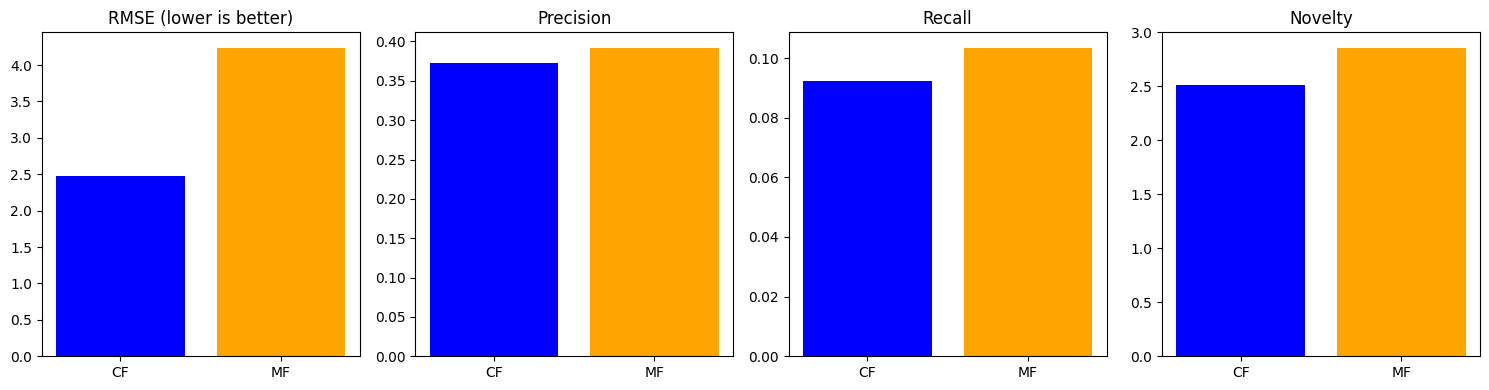

In [94]:
# data
models = ['CF', 'MF']
metrics = {
    'RMSE (lower is better)': [cf_results[0], mf_results[0]],
    'Precision': [cf_results[1], mf_results[1]],
    'Recall': [cf_results[2], mf_results[2]],
    'Novelty': [cf_results[3], mf_results[3]]
}

# create 4 plots
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, (name, values) in enumerate(metrics.items()):
    ax = axes[i]
    ax.bar(models, values, color=['blue', 'orange'])
    ax.set_title(name)
plt.tight_layout()
plt.savefig('comparison_results.png')
plt.show()

## Prediction for Test Users

Cold Start

In [95]:
# calculate global popularity for users not present in the training set (high review scores and count)
movie_stats = df_combined.groupby('movieId').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'vote_count']

# filter for movies with at least 50 ratings
popular_movies_list = movie_stats[movie_stats['vote_count'] > 50] \
    .sort_values(by='avg_rating', ascending=False) \
    .index.tolist()

# take top 10
top_10_popular = popular_movies_list[:10]
print(f"Popularity Fallbacks: {top_10_popular}")

Popularity Fallbacks: [318, 858, 1276, 750, 1213, 2959, 1208, 1221, 904, 912]


Get Recommendations

In [96]:
def get_user_recommendations(user_id, pivot, preds_df, fallback_list, k=10):
    """
    Retrieves 10 movie IDs for a user using Matrix Factorization (SVD).
    Falls back to popularity for cold cases.
    """
    # check if user exists in our reconstructed matrix
    if user_id in preds_df.index:
        # get MF recommendations
        recs = run_matrix_factorization(user_id, pivot, preds_df, count=k)
        final_list = recs.index.tolist()

        # padding (popularity)
        if len(final_list) < k:
            padding = [m for m in fallback_list if m not in final_list]
            final_list.extend(padding[:(k - len(final_list))])
        return final_list[:k]
    else:
        # cold start (popularity)
        return fallback_list[:k]

# generate recommendations for every user
print("Generating recommendations for every user...")
unique_test_users = test_df['userId'].unique()
submission_rows = []
for user in unique_test_users:
    top_10 = get_user_recommendations(user, pivot_cf, preds_df, top_10_popular, k=10)
    submission_rows.append([user] + top_10)

Generating recommendations for every user...


Output Dataframe

In [97]:
# create df
columns = ['userId'] + [f'recommendation{i}' for i in range(1, 11)]
final_submission_df = pd.DataFrame(submission_rows, columns=columns)

# save to csv
final_submission_df.to_csv('ratings_test_filled.csv', index=False)
display(final_submission_df.head())

,userId,recommendation1,recommendation2,recommendation3,recommendation4,recommendation5,recommendation6,recommendation7,recommendation8,recommendation9,recommendation10
0,3,1200,1214,1240,1258,593,1097,1196,1215,2640,2985
1,7,2571,1198,110,2028,8961,1270,6539,527,1580,6377
2,11,527,2571,648,150,1036,589,590,592,2762,349
3,25,1196,2959,79132,593,1210,356,1704,2762,91529,318
4,30,1196,58559,356,2959,1270,858,4886,296,593,527
